# Precipitation Model Testing Using ERA5 Data

This Jupyter Notebook tests a precipitation model using ERA5 reanalysis data as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature

- **Atmospheric Profile Inputs** (from ERA5 Pressure Levels):
  - Temperature at pressure levels
  - Specific humidity at pressure levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **ERA5 Single Levels** (ECMWF): for 2m temperature, dew point, and surface pressure  
- **ERA5 Pressure Levels** (ECMWF): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_era_data.ipynb

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights_new as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from entrainment_new import calculate_profiles_with_entrainment,lcl_enrtainment_from_ground
import condensation_fluxes
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the data

Interactive cell for initializing the model settings. Choose the desired values, click Apply Settings and then Run All cells again or Run below.

In [2]:
%run widgets.py

The input data used in this model consist of a combined dataset derived from **ERA5 surface values** and **ERA5 atmospheric profiles**.

- **Surface variables** include:
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature
  - Specific humidity at the surface

- **Atmospheric profile variables** include:
  - Temperature at multiple pressure levels
  - Pressure levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [3]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

if interp_interval != 'No':
    time_dim = 'valid_time'
    data_era_min = data_era.resample({time_dim: interp_interval}).interpolate('linear')
    data_era = data_era_min.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [4]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [5]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values 
q_v_air = data_era.specific_humidity.values      

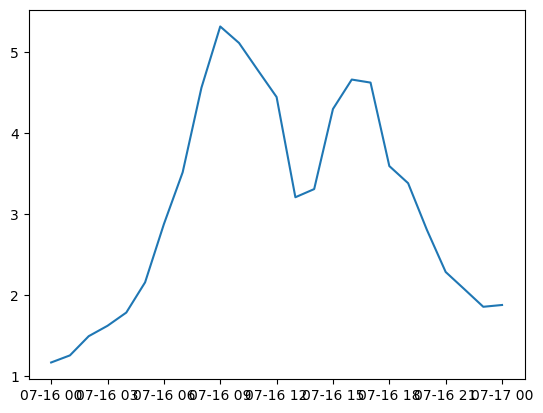

In [6]:
plt.plot(time,T_air[:,0] - T_d)
plt.show()

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance.

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
rain_rate_10min = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
#hourly_avg = rain_rate.resample(time='1H').mean()
hourly_acc = rain_rate.resample(time="5min").sum()

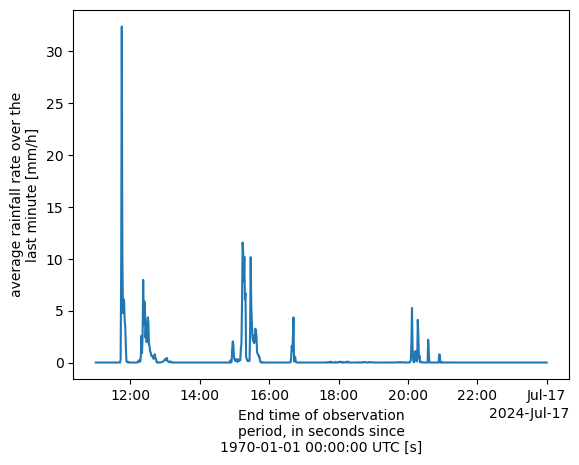

In [8]:
rain_rate.sel(time=slice("2024-07-16T11:00:00","2024-07-17T13:00:00")).plot()
plt.show()

## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [9]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to later include the LCL values explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [10]:
temp_parcel = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel_new = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [11]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):

    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i,0])
    temp_parcel[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel_new[i,:],int(lcl_index[i]),theta_type=theta_type)

a 288.94847493773653
a 288.8150729168578
a 288.41699215555127
a 287.829410222252
a 287.09256174993004
a 286.52834144218457
a 285.92168408284346
a 286.65825930358955
a 287.1926010905292
a 286.7609518850276
a 287.08358285806133
a 287.16775078246206
a 287.0635798230172
a 286.8904295745428


In [12]:
T_air

array([[290.68054, 291.86816, 292.8734 , 291.87195, 290.4812 , 288.82422,
        287.05627, 285.3811 , 283.79797, 281.99927, 279.88477, 277.99817,
        274.86798, 271.4469 , 267.62476, 263.79456, 259.1588 , 253.56956,
        247.54942, 241.26764, 233.36008, 225.01028, 222.84267, 226.14165],
       [290.4928 , 291.5448 , 291.56384, 290.60645, 289.51318, 288.14258,
        286.72925, 285.32446, 283.76343, 281.96973, 280.02808, 278.19434,
        274.72015, 270.8838 , 267.09906, 263.0841 , 258.12305, 253.02528,
        248.10466, 241.82564, 233.21147, 225.73448, 224.145  , 225.90796],
       [290.65125, 291.2268 , 290.33386, 289.44983, 288.94543, 287.8717 ,
        286.45862, 284.89624, 283.10767, 281.43018, 279.68323, 278.0835 ,
        274.70178, 270.86176, 266.81104, 262.53528, 257.39935, 252.62967,
        248.50677, 241.99962, 232.68024, 225.68524, 224.57387, 225.99403],
       [290.4104 , 290.35767, 289.19434, 287.72412, 286.9464 , 286.4928 ,
        285.2262 , 283.62927, 282.1

In [13]:
negs = (q_v_parcel < 0).sum()
print(f"Number of negative values in q_l_new: {negs}")

Number of negative values in q_l_new: 0


#### Calculate the environmental virtual temperature profiles

In [14]:
T_v_env = air_temp_new*(1+0.61*q_v_new)

### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [15]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

ValueError: too many values to unpack (expected 2)

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [ ]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel_new[i])

### Entrainment calculations

Cell that automatically selects the correct index of cloud height to implement entrainment from, based on the user selection

In [ ]:
if entrainment_beginning=='from LCL':
    start_index = lcl_index + 1
elif entrainment_beginning=='from ground':
    start_index = np.ones(lcl_index.shape[0])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [ ]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))
Theta_air_arr = np.zeros((rows,cols+1))
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = np.zeros((rows,cols+1))
for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i],q_l_new[i],q_v_parcel_new[i],Theta_air_arr[i] = calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel_new[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(start_index[i]), entrainment_rate, theta_type)


In [ ]:
# if entrainment starts from the ground, then the LCL changes so it has to be recalculated and interpolated
if entrainment_beginning=='from ground':

    for i in range(0,rows):
    #print(i)
        entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
        
        temp_parcel[i] = np.delete(T_parcel_new[i],int(lcl_index[i]))
        p_air[i] = np.delete(p_new[i],int(lcl_index[i]))
        Z[i] = np.delete(Z_new[i],int(lcl_index[i]))
        T_air[i] = np.delete(air_temp_new[i],int(lcl_index[i]))
        q_v_air[i] = np.delete(q_v_new[i],int(lcl_index[i]))

        lcl_index[i],T_s[i],p_s[i] = lcl_enrtainment_from_ground(T_parcel_new[i],p_new[i],T_d[i],Z_new[i])
        lcl_index[i] = np.clip(int(lcl_index[i]), 0, len(p_air[i]) - 3)     #for cases where the LCL is in very high altitude

        #interpolation at the lcl level
        T_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])
    



Calculating the new parcel virtual temperature profile after considering entrainment 

In [ ]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

#### LFC height

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [ ]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [ ]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

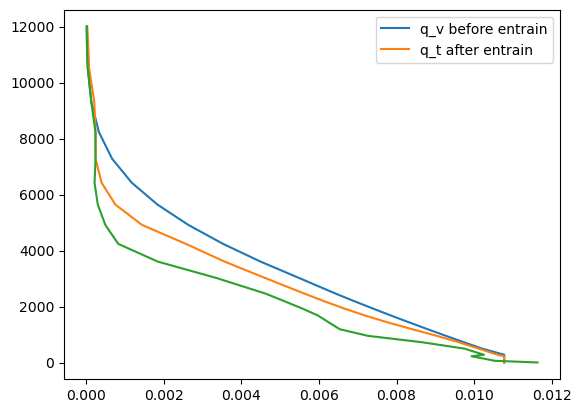

In [ ]:
index = 4
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_v_parcel[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_t after entrain')
plt.plot(q_v_new[index],Z_new[index])
#plt.plot(q_v_parcel_new[index],Z_new[index])
#plt.plot(q_l_new[index],Z_new[index])
#plt.axhline(y=Z_new[index,int(lcl_index[index+1])],color='blue')
#plt.axhline(y=Z_t[index],color='green')
#plt.axhline(y=Z_t_new[index],color='red')
plt.legend()
plt.show()

In [ ]:
def find_top_index(Z_t_new,Z_c_new,Z_new):
    if Z_t_new == 0 or Z_c_new == 1:  
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new - Z_new) <= 0)
    return top_index

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [ ]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],top_index)

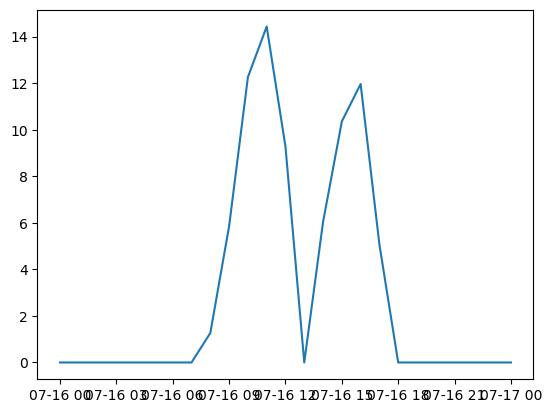

In [ ]:
plt.plot(time,w_parcel_max)
plt.show()

In [ ]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [ ]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])  

    w_avg = w_parcel_max[i]/2
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = condensation_fluxes.condensation_flux(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index,theta_type=theta_type)

    if i<rows-1:
        #if X[i]/Z_c_new[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            #X[i] = 2.5e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - min(X[i] - thresh*Z_c_new[i],ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i])# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])

In [ ]:
X[15] + f_arr[15]*dt_seconds[15] - ar.cloud_water_autoconversion_rate(X[15],Z_c_new[15],thresh)*dt_seconds[15]

-34.309267928904006

In [ ]:
ar.cloud_water_autoconversion_rate(X[15],Z_c_new[15],thresh)*dt_seconds[15]

146.10501287457808

In [ ]:
(X[15] - Z_c_new[15]*thresh)*dt_seconds[15]/1000

146.1050128745781

In [ ]:
X

array([0.00000000e+00, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 1.30178170e+00, 3.00903338e+01, 1.05877267e+02,
       1.26300526e+02, 7.35305732e+01, 5.00000000e-04, 4.16762886e+01,
       7.12110191e+01, 8.18393280e+01, 2.32269554e+01, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04])

In [ ]:
total_water = np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    if theta_type == "GB84" or theta_type == "theta_e":         #in pseudoadiabatic approach water is constantly removed, 
        total_water[i] = np.sum(q_l_new[i,int(lcl_index[i]):int(top_index)+1])                                                   #so integrate over all cloud heights
    
    else:                                                       #in reversible approach water is staying inside the parcel,
        total_water[i] = q_l_new[i,int(top_index)]                                                  #so total water is what reaches the cloud top

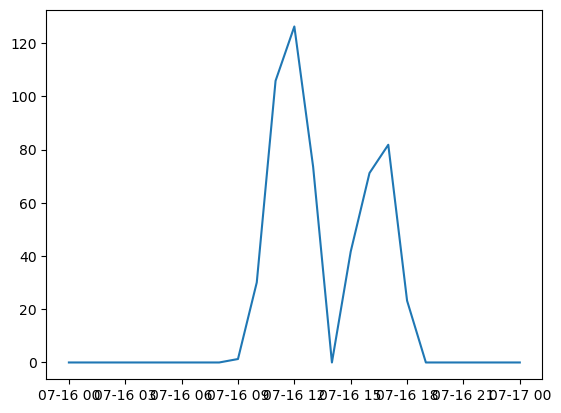

In [ ]:
plt.plot(time,X)
plt.show()

### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [ ]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    #print(i)
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    w_avg = w_parcel_max[i]/2
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_avg*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_avg*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_avg*100,alpha)

8.51879243025631 99.39363112620478
-0.8866128802525113 8.929470660779591
-1.3644998510781057 4.916468382012421
-1.3648527231160774 4.913521081540991
-1.0522308518733183 7.533804297422756
-0.9924158999564994 8.037260587668213
-1.226924059595545 6.067320032855979
-1.1796908881495178 6.46325556009982
-0.09712229197518352 15.656194013030511


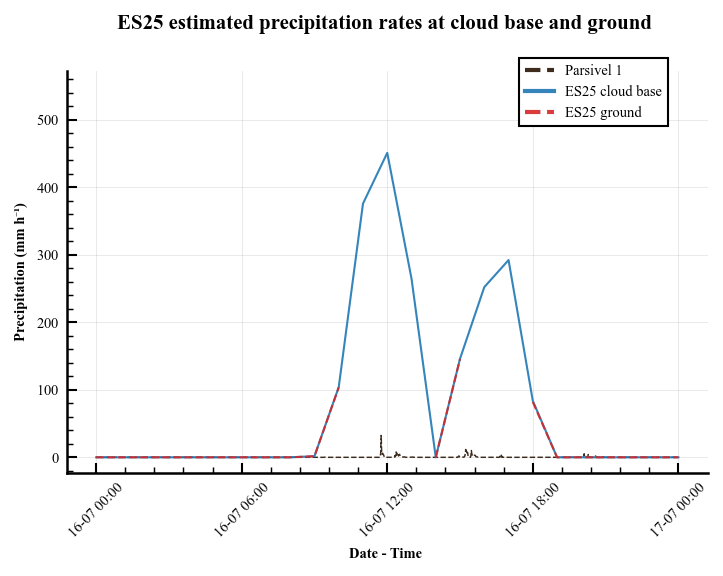

In [ ]:
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 7,
    'axes.titlesize': 10,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 7,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(5, 4))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
##ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

line_2 = ax1.plot(rain_rate.time, rain_rate, 
                color=colors['updraft'], 
                linestyle='--', 
                linewidth=0.7,
                label='Parsivel 1',
                alpha=0.9)
# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, R*3600, 
                color=colors['inflow'], 
                linestyle='-', 
                linewidth=1.0,
                label='ES25 cloud base',
                alpha=0.9)

# Plot updraft velocity on right axis (ax2)
line4 = ax1.plot(time, P*3600, 
                color=colors['outflow_bottom'], 
                linestyle='--', 
                linewidth=1.0,
                label='ES25 ground',
                alpha=0.9)


#ax1.hlines(y=np.min(X[mask]), xmin=time[mask].min(), xmax=time[mask].max(),)
# Set updraft velocity y-axis to start from 0 and leave space at top
#ax2.set_ylim(bottom=0)

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()


ax1_range = ax1_ylim[1] - ax1_ylim[0]


ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)


# ADD PRECIPITATION SHADING HERE
# Get updated y-limits after extension for proper shading
y_min, y_max = ax1.get_ylim()

# Add red shaded areas for precipitation
# Assuming you have P*3600 and rain_rate variables
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)


# Optionally add shading for actual rain rate with different color/alpha
#ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 #alpha=0.2, color='orange', label='Rain rate > 0.2 mm/h', interpolate=True)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Precipitation (mm h⁻¹)', color='black', fontweight='bold')

ax1.set_title('ES25 estimated precipitation rates at cloud base and ground ', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')


# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()


# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)

# Professional y-axis formatting for ax2
#ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#ax2.yaxis.get_offset_text().set_fontsize(11)

# Proper time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# Combine legends from both axes AND precipitation shading
lines1, labels1 = ax1.get_legend_handles_labels()


# Scientific legend positioning
legend = ax1.legend(lines1 , labels1 ,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1.05),
                   ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

## Visualizing the outputs

#### Rainfall rate

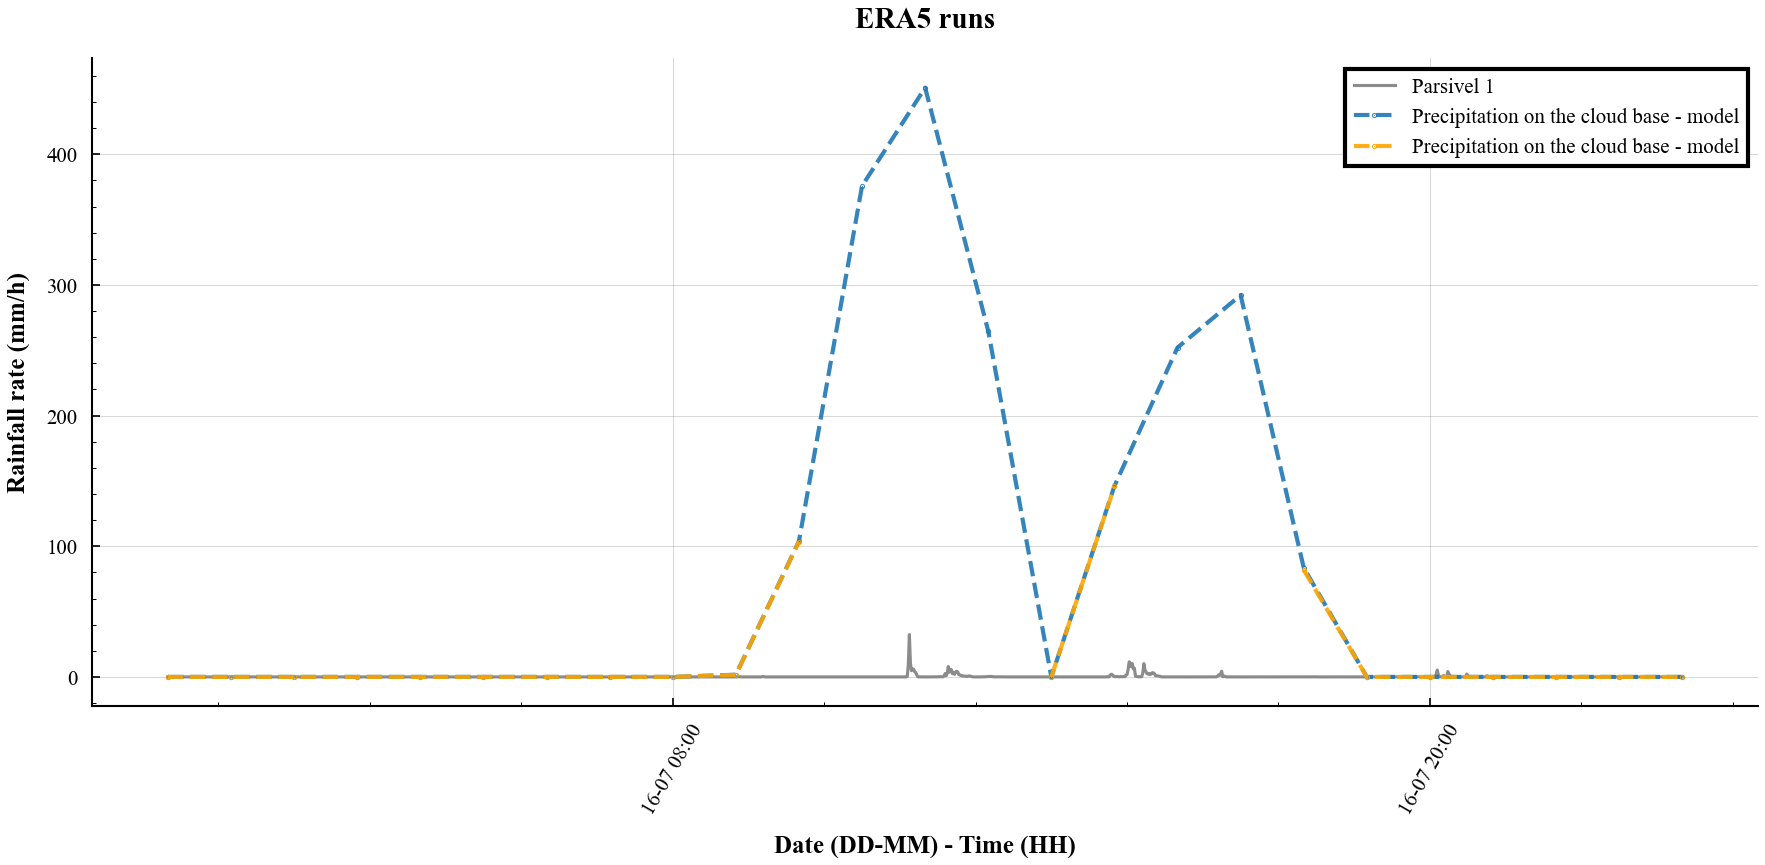

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time, R * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    marker='o',
                    markersize=0.5 * SCALE_FACTOR,
                    alpha=0.9)

line_model_2 = ax.plot(time, P * 3600, 
                    color='orange', 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    marker='o',
                    markersize=0.5 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=1 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 24  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'rainfall_rate_era5_entrainment.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')
#             format='pdf', dpi=600, bbox_inches='tight')

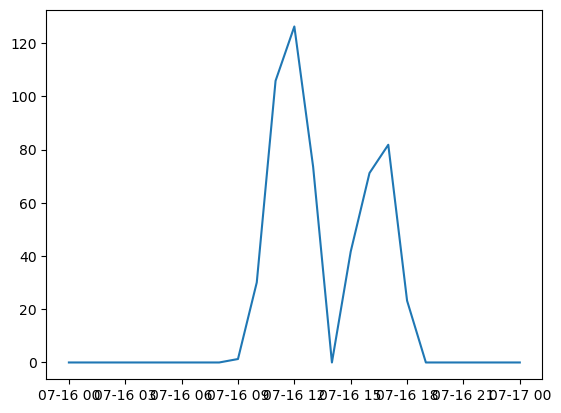

In [ ]:
#plt.plot(time,R*3600)
plt.plot(time,X)
plt.show()

In [ ]:
mask = np.isnan(P)

# Count NaNs
count_nans = np.sum(mask)
print(count_nans)

5


In [ ]:
import pickle
import pandas as pd
import numpy as np
from datetime import datetime

# Method 1: Save as pickle (preserves exact Python objects including datetime)
def save_datasets_pickle():
    """Save all datasets as pickle files"""
    datasets = {
        'rain_rate': rain_rate,
        'time': time,
        "state":X,
        'R': R,
        'Z_t': Z_t,
        'Z_t_new': Z_t_new,
        'metadata': {
            'theta_type': theta_type,
            'entrainment_beginning': entrainment_beginning,
            'slice_str': slice_str,
            'slice_tuple': slice_tuple,
            'start_dt': start_dt,
            'end_dt': end_dt,
            'save_timestamp': datetime.now().isoformat()
        }
    }
    
    with open('era5_datasets_sens_T_plus.pkl', 'wb') as f:
        pickle.dump(datasets, f)
    
    print("✓ Datasets saved as era5_datasets_T_plus.pkl")

In [ ]:
save_datasets_pickle()

✓ Datasets saved as era5_datasets_T_plus.pkl


import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'hourly_avg': '#1f77b4',     # Blue
    'model': '#ff7f0e',          # Orange
}

# Plot with scaled line widths
ax.plot(time_dt, hourly_avg,
        color=colors['hourly_avg'], 
        label='Hourly average Parsivel 1',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

ax.plot(time_dt, R * 3600,
        color=colors['model'], 
        label='Model precipitation',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Precipitation rate (mm/h)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Precipitation Comparison: Observations vs Model',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper right',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

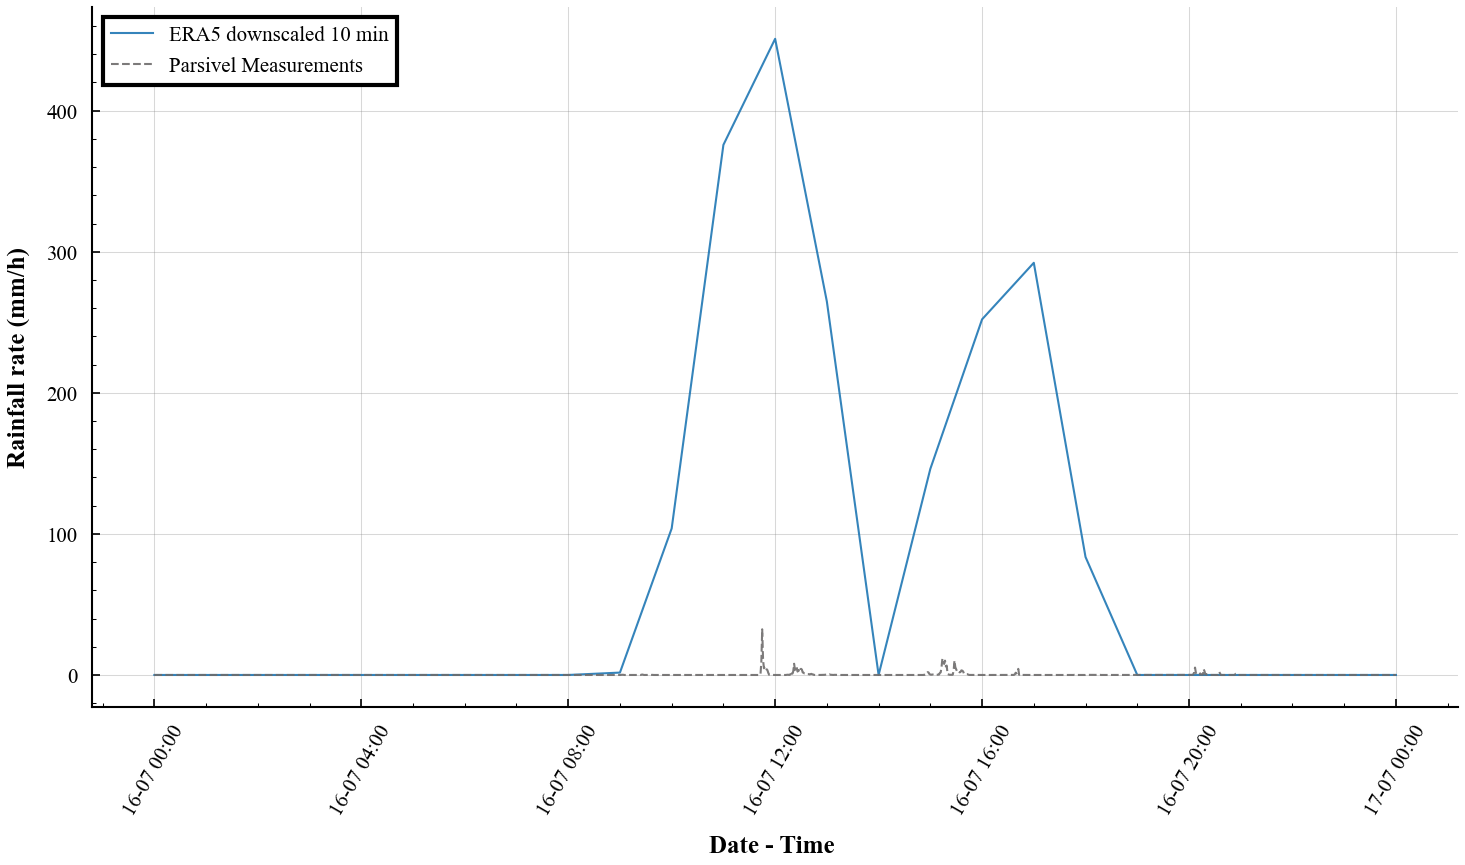

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure with two horizontal subplots - scaled by SCALE_FACTOR
fig,ax2 = plt.subplots(figsize=(10 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': "#6e6c6c00",      # Red - spline linear
    'cubic': '#ff7f0e',        # Orange - cubic
    'no_entrainment': '#d62728'  # Red  
}


# ==================== SUBPLOT 1: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR


line1_model = ax2.plot(time, R*3600, 
                      color=colors2['era5_10'], 
                      label='ERA5 downscaled 10 min',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)
line_3 = ax2.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      linestyle='--', 
                      label='Parsivel Measurements',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Date - Time ', fontweight='bold')
ax2.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')


# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper left',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax2.ticklabel_format(style='plain', axis='y')
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 2  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 4  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'
    rotation = 45

# Apply time formatting to both subplots


# Apply time formatting
ax2.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Overall figure title
# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
count_prec = np.sum((rain_rate_10min>0.38) & (P*3600 > 0))
count_no_prec = np.sum((rain_rate_10min==0) & (P*3600==0))
count_model_dubious = np.sum(
    (rain_rate_10min> 0) & (rain_rate_10min <= 0.38) & (P * 3600 == 0)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate_10min==0) & (P*3600 > 0)) + np.sum((rain_rate_10min > 0) & (rain_rate_10min <= 0.38) & (P*3600 > 0))
count_wrong_zero = np.sum((rain_rate_10min>0.38) & (P*3600 == 0))

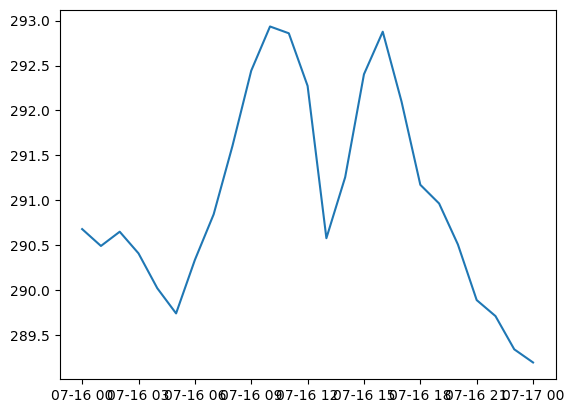

In [ ]:
plt.plot(time,T_air[:,0])
plt.show()

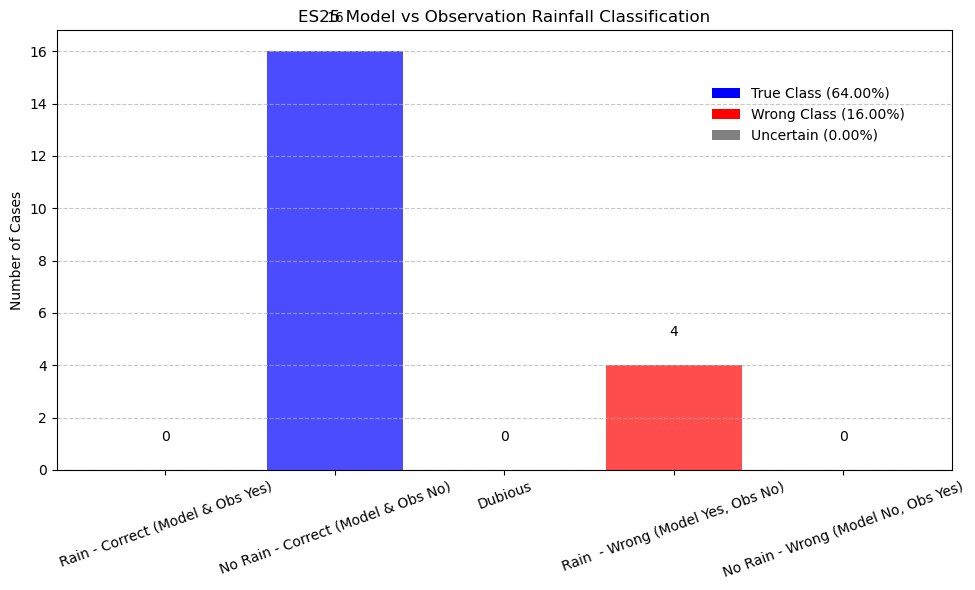

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/len(time)*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/len(time)*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/len(time)*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("ES25 Model vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import scipy.stats as stats
mask_rain = R > 0
pearson = stats.pearsonr((T_air[mask_rain,0]),(P[mask_rain]))

ValueError: array must not contain infs or NaNs

In [ ]:
pearson  = stats.pearsonr((T_air[mask_rain,0] - T_d[mask_rain]),(P[mask_rain]))

In [ ]:
pearson = stats.pearsonr((T_d[mask_rain]),(P[mask_rain]))

In [ ]:
pearson

PearsonRResult(statistic=0.7126134023343054, pvalue=6.875823263204043e-15)

#### Virtual Temperature profiles at different times

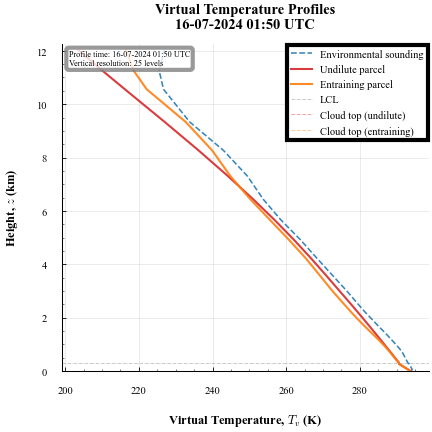

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.25  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient = ax.plot(T_v_env[index_2], Z_new[index_2]/1000,  # Convert to km
                      color=colors['ambient'], 
                      label='Environmental sounding',
                      linestyle='--', 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_dry = ax.plot(T_v_moist[index_2], Z_new[index_2]/1000,
                  color=colors['no_entrainment'], 
                  label='Undilute parcel',
                  linestyle='-', 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)

line_entrain = ax.plot(T_v_moist_new[index_2], Z_new[index_2]/1000,
                      color=colors['with_entrainment'], 
                      label='Entraining parcel',
                      linestyle='-', 
                      linewidth=2.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Height, $z$ (km)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR
lcl_line = ax.axhline(y=Z_new[index_2,int(lcl_index[index_2])]/1000, 
                     color='grey', linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                     label='LCL')

zt_line = ax.axhline(y=Z_t[index_2]/1000, 
                    color=colors['no_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                    label='Cloud top (undilute)')

zt_new_line = ax.axhline(y=Z_t_new[index_2]/1000, 
                        color=colors['with_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                        label='Cloud top (entraining)')

# Set axis limits with some padding for scientific presentation
temp_range = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
              np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding = (temp_range[1] - temp_range[0]) * 0.05
ax.set_xlim(temp_range[0] - temp_padding, temp_range[1] + temp_padding)

height_max = Z_new[index_2].max()/1000
ax.set_ylim(0, height_max * 1.02)

# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='x')
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()

# Optional: Add metadata text box for scientific context - scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8 * SCALE_FACTOR,
        verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

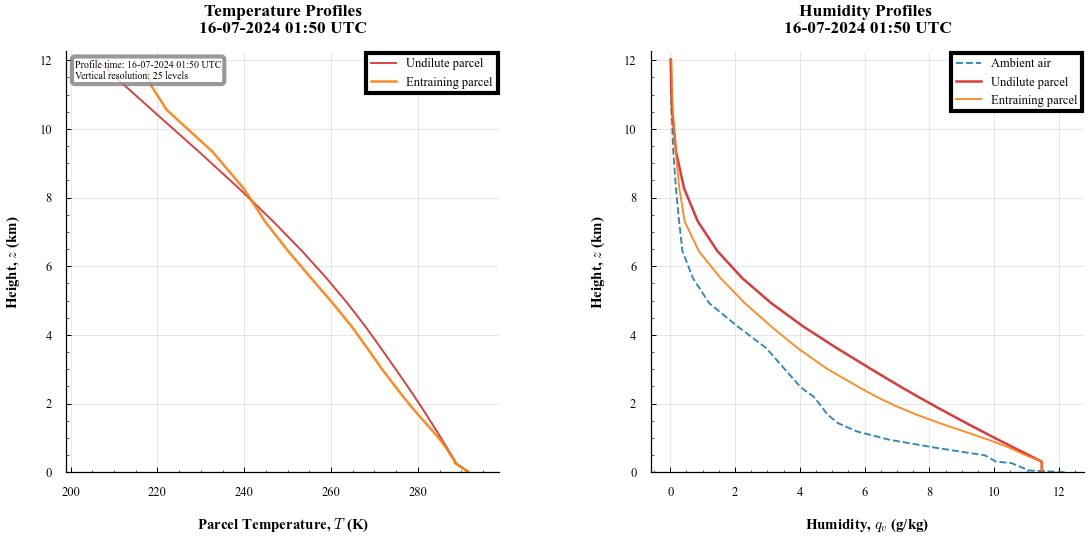

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots side by side - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')

# ===== LEFT SUBPLOT (ax1) =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient1 = ax1.plot(temp_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['no_entrainment'], 
                        label='Undilute parcel', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry1 = ax1.plot(T_parcel_new[index_2], Z_new[index_2]/1000,
                    color=colors['with_entrainment'], 
                    label='Entraining parcel',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

# Scientific axis labels with units
ax1.set_xlabel('Parcel Temperature, $T$ (K)', fontweight='bold')
ax1.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax1.set_title(f'Temperature Profiles\n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Set axis limits with some padding for scientific presentation
temp_range1 = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
               np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding1 = (temp_range1[1] - temp_range1[0]) * 0.05
ax1.set_xlim(temp_range1[0] - temp_padding1, temp_range1[1] + temp_padding1)

height_max1 = Z_new[index_2].max()/1000
ax1.set_ylim(0, height_max1 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend1 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# ===== RIGHT SUBPLOT (ax2) - Duplicate =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient2 = ax2.plot(1000*q_v_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['ambient'], 
                        label='Ambient air',
                        linestyle='--', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry2 = ax2.plot(1000*q_v_parcel[index_2], Z_new[index_2]/1000,
                    color=colors['no_entrainment'], 
                    label='Undilute parcel',
                    linestyle='-', 
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

line_moist = ax2.plot(1000*q_v_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['with_entrainment'], 
                        label='Entraining parcel',
                        linestyle='-', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Humidity, $q_v$ (g/kg)', fontweight='bold')
ax2.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax2.set_title(f'Humidity Profiles \n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Add horizontal reference lines with labels

height_max2 = Z_new[index_2].max()/1000
ax2.set_ylim(0, height_max2 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting for both subplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    
    # Ensure scientific notation if needed
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adjust spacing manually instead of tight_layout to preserve subplot spacing
plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.12, wspace=0.35)

# Optional: Add metadata text box for scientific context - only on left subplot, scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=8 * SCALE_FACTOR,
         verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

#### Cloud top and base

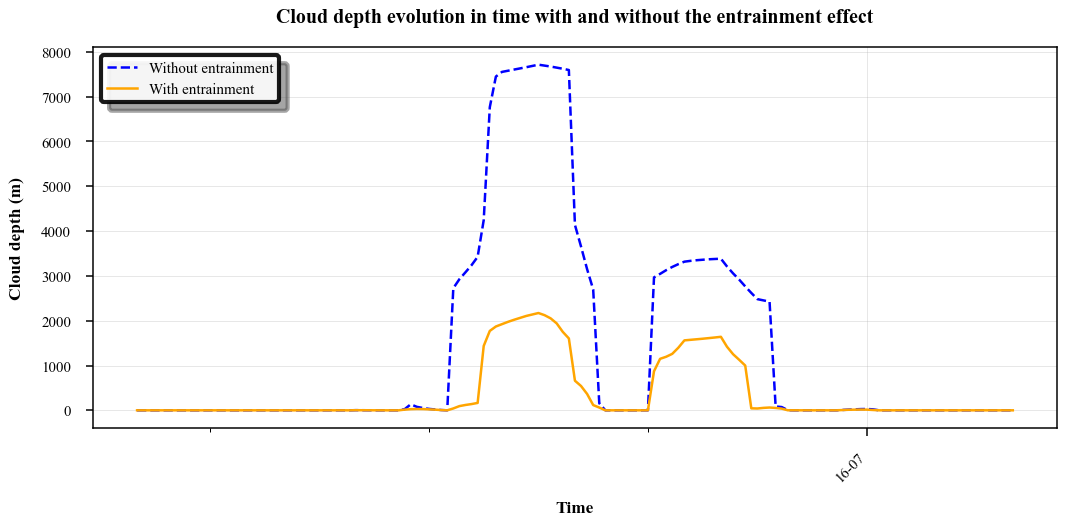

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, np.maximum(0, Z_t - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='blue', 
        label='Without entrainment',
        linestyle='--',
        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, np.maximum(0, Z_t_new - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

#### Updraft velocity

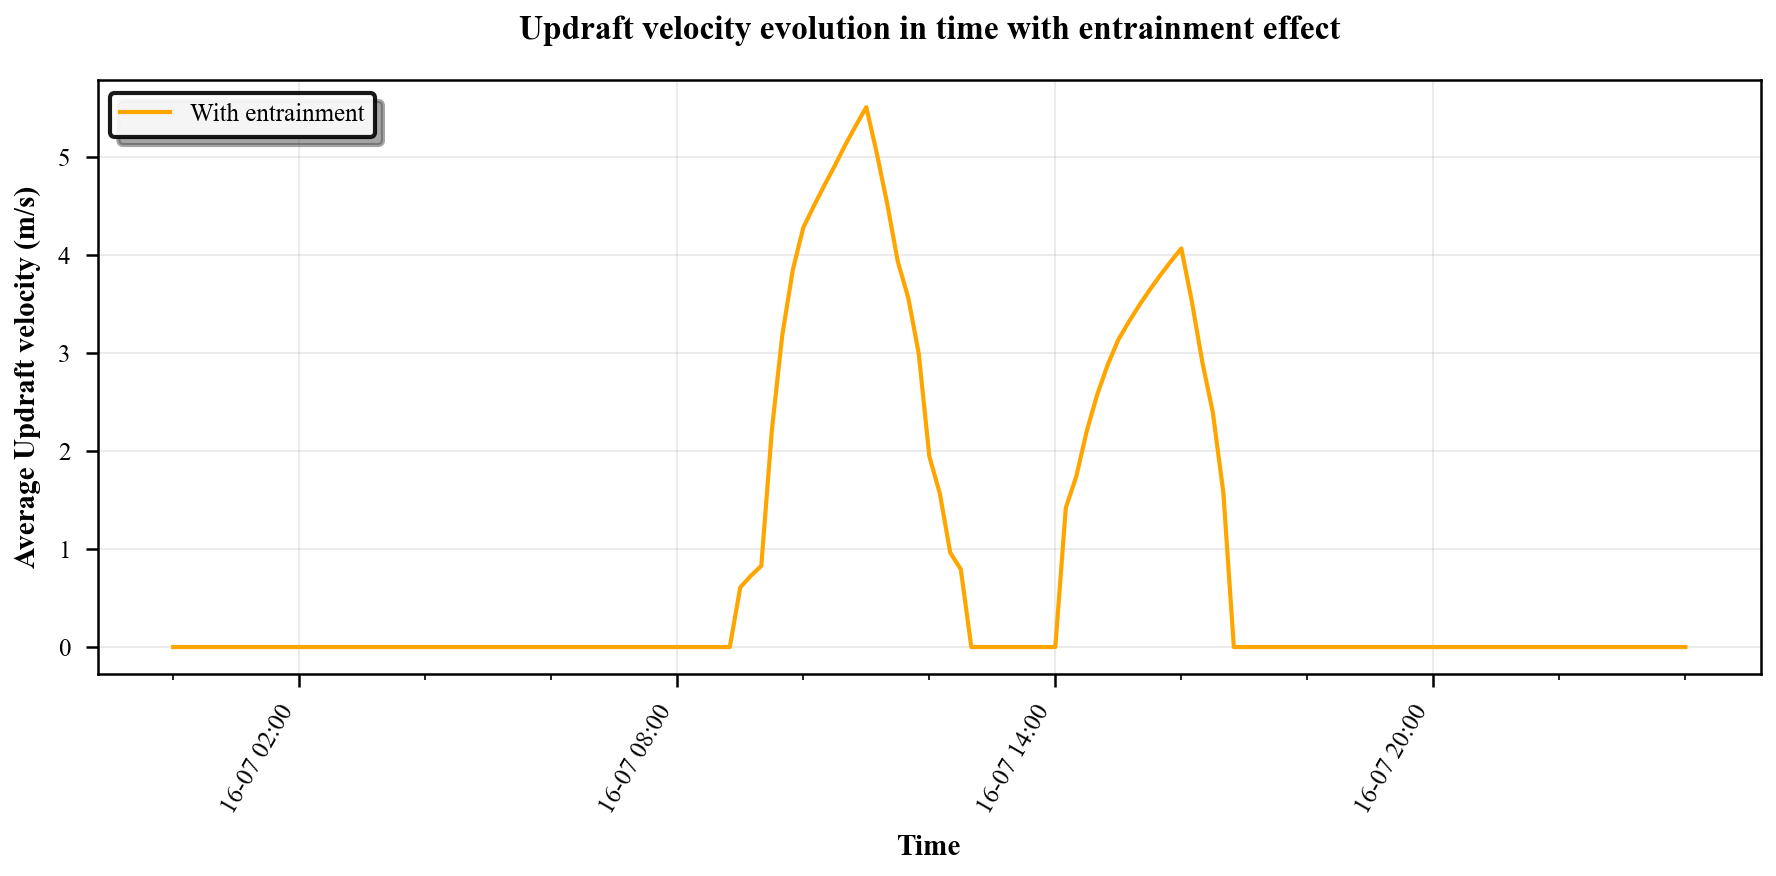

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
#ax.plot(time_dt, w_parcel_max_old/2,
#        color='blue', label='Without entrainment', linestyle='--', 
#        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, w_parcel_max/2,
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Average Updraft velocity (m/s)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Updraft velocity evolution in time with entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
indices = np.where(R*3600>0.2)[0]
np.mean(w_parcel_max[indices]/2)

2.5797809238046643

In [ ]:
len(X)

145

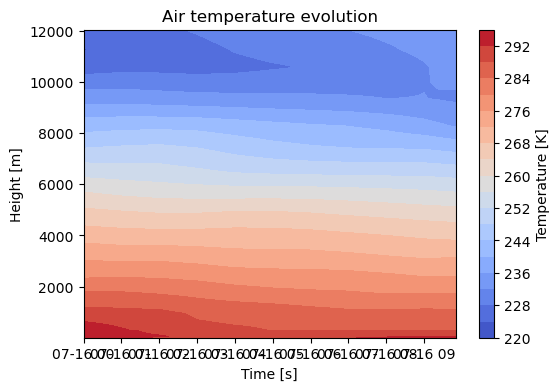

In [ ]:

T, Zgrid = np.meshgrid(time[:60], Z_new[0])  # build 2D grid
plt.figure(figsize=(6,4))
cp = plt.contourf(T, Zgrid, air_temp_new[:60,:].T, levels=20, cmap="coolwarm")

plt.colorbar(cp, label="Temperature [K]")
plt.xlabel("Time [s]")
plt.ylabel("Height [m]")
plt.title("Air temperature evolution")
plt.show()


In [ ]:
index = np.where(f_arr>0)
f_arr_mean = np.mean(f_arr[index])
#np.mean(q_l_new[index,int(lcl_index[index]):int(find_top_index(Z_new[index],lcl_index[index]))])

In [ ]:
Z_c_new[8]

1.0

In [ ]:
index = np.where(Z_c>1)
Z_c_mean = np.mean(Z_c[index])

In [ ]:
np.where(X>0)

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
        131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144], dtype=int64),)

In [ ]:
time[8]

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2024-07-16T01:20:00.000000000', dtype='datetime64[ns]')
Coordinates:
    latitude    float64 8B 52.0
    longitude   float64 8B 5.0
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2024-07-16T01:20:00
Attributes:
    long_name:      time
    standard_name:  time

In [ ]:
a_autoconversion = 0.001
def X_series_1(f_arr_mean,X0,n,dt_time):
    
    #if X0 < thresh*Z_c_mean:
    X_n = X0 + n*f_arr_mean*dt_time
    return X_n

def X_series_2(Z_c_mean,f_arr_mean,X0,n,dt_time):
    X_n = (1-a_autoconversion*dt_time)**n * X0 + (f_arr_mean/a_autoconversion + thresh*Z_c_mean)*(1 - (1-a_autoconversion*dt_time)**(n))
    return X_n

In [ ]:

timestep = 1800
n = int(3600/timestep)
X_n_series = np.zeros([24,n])
X_0 = X[0]  # initial state at 8:00
#X_n_series_9 = np.zeros(n)
#X_n_series_9[0] = X_0
j = 0  # counter since last regime reset
X_n_series[0][0] = X_0
for a in range(24):
    j = 0
    if a>0:
        X_n_series[a][0] = X_n_series[a-1][-1]
        X_0 = X_n_series[a][0]
    for i in range(1, n):
        j += 1
    
        if X_n_series[a][i-1] < thresh * Z_c_new[a]:
            print(j)
            # Non-precipitating branch
            X_n = X_series_1(f_arr[a], X_0, j, timestep)
            X_n = max(0, X_n)
        # If threshold crossed -> reset
            if X_n >= thresh * Z_c_new[a]:
                X_0 = X_n
                j = 0
    
        else:
            # Precipitating branch
        
            X_n = X_series_2(Z_c_new[a]-1, f_arr[a], X_0, j, timestep)
            print(X_n)
            X_n = max(0, X_n)
            # If it drops below threshold -> reset
            if X_n < thresh * Z_c_new[a]:
                X_0 = X_n
                j = 0
        
        X_n_series[a][i] = X_n

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [ ]:
n

2

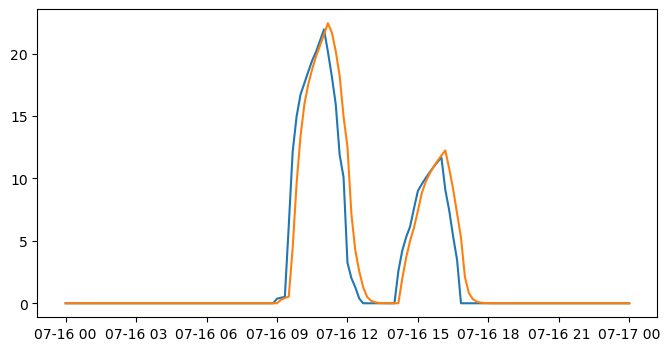

In [ ]:
fig = plt.figure(figsize=(8,4))
plt.plot(time,f_arr*1000)
plt.plot(time,X)
plt.show()

In [ ]:
plt.plot(T_air[:,0] - T_d)

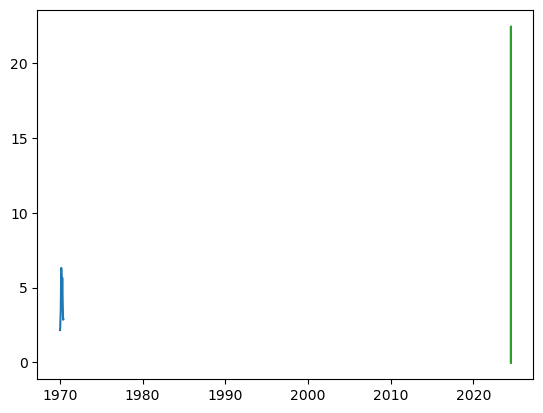

In [ ]:
plt.plot(rain_rate.time[0::30][:-1],X_n_series.reshape(-1))
plt.plot(time,X)
plt.show()

In [ ]:
f_arr[14]

0.0

In [ ]:
X[9]

0.0005

In [ ]:
time_downscale = rain_rate.time.sel(time=slice('2024-07-16T00:00:00.000000000','2024-07-16T23:59:00.000000000'))

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)
# Example: every hour instead of every 3 hours
tick_interval = 1.0   # major ticks every hour
minor_interval = 0.5  # minor ticks every 30 minutes
# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model= ax.plot(time_downscale,X_n_series.reshape(-1),  # Convert to km
                      color=colors['ambient'], 
                      label='1min time step',
                      linestyle='--',
                      marker = 'o',
                      markersize = 0.5, 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_downscaled = ax.plot(time,X,
                  color=colors['no_entrainment'], 
                  label='1hr time step',
                  linestyle='-', 
                  marker = 'o',
                  markersize = 1, 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)



# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Cloud water, $X$ (kg/m2)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR


# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper left',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

# Minor ticks every 30 minutes
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('LWC (g/m³)', fontweight='bold')
ax.set_xlabel('Date - Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

ValueError: x and y must have same first dimension, but have shapes (1440,) and (48,)

In [ ]:
R_n_series = np.zeros(len(X_n_series.reshape(-1)))
for i in range(len(X_n_series.reshape(-1))):
    #j = i%60
    a = 0 + i//60
    #if j == 0:
    p = i - 60*((i//60))
    print(a,p)
    R_n_series[i] = ar.cloud_water_autoconversion_rate(X_n_series[a,p],Z_c_new[a],thresh)

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
1 40
1 41
1 42
1 43
1 44
1 45
1 46
1 47
1 48
1 49
1 50
1 51
1 52
1 53
1 54
1 55
1 56
1 57
1 58
1 59
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
2 21
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
2 30
2 31
2 32
2 33
2 34
2 35
2 36
2 37
2 38
2 39
2 40
2 41
2 42
2 43
2 44
2 45
2 46
2 47
2 48
2 49
2 50
2 51
2 52
2 53
2 54
2 55
2 56
2 57
2 58
2 59
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27


In [ ]:
f_arr[16]*60

0.0

In [ ]:
X_n_series[0] - thresh*Z_c_new[8]

array([-0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005, -0.0005,
       -0.0005, -0.0005, -0.0005, -0.0005])

In [ ]:
X_n_series.reshape(-1)

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
R_n_series.reshape(-1)

array([0., 0., 0., ..., 0., 0., 0.])

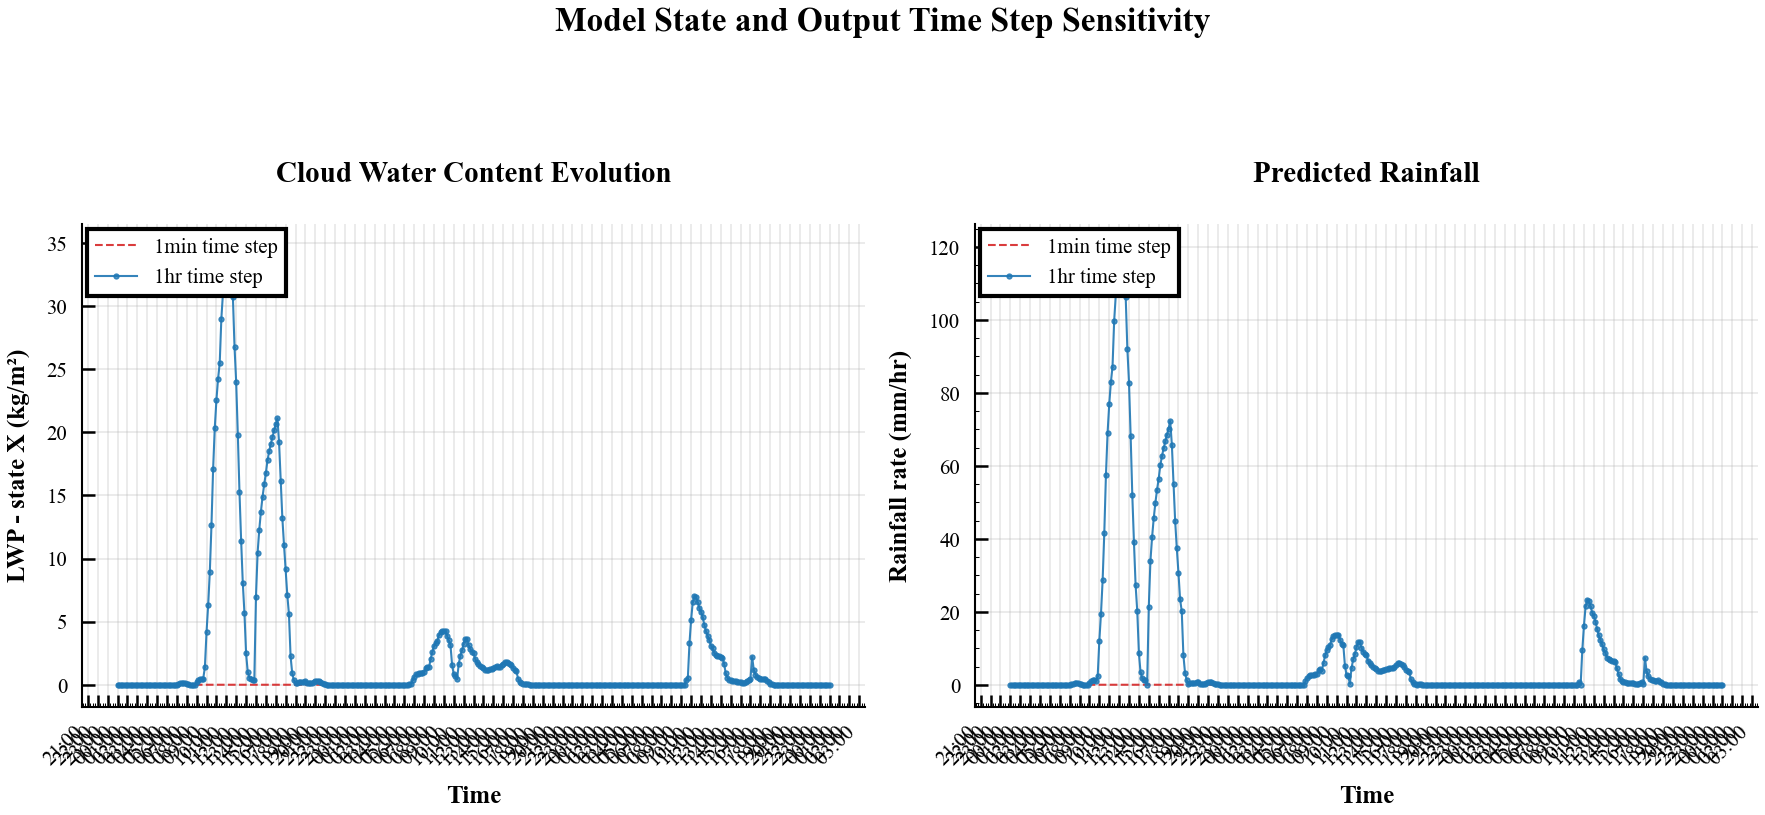

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.
#ratio_series = (X_n_series.T / Z_c_new).T * 1000
# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12 * SCALE_FACTOR, 5* SCALE_FACTOR), 
                               sharex=True)

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# ==================== SUBPLOT 1: LWC (Cloud Water Content) ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model_lwc = ax1.plot(time_downscale, X_n_series.reshape(-1),  # Convert to g/m³
                          color=colors['no_entrainment'], 
                          label='1min time step',
                          linestyle='--', 
 
                          linewidth=1 * SCALE_FACTOR,
                          alpha=0.9)

line_downscaled_lwc = ax1.plot(time, X,
                               color=colors['ambient'], 
                               label='1hr time step',
                               linestyle='-', 
                                                         marker = 'o',
                          markersize = 0.5,
                               linewidth=1.0 * SCALE_FACTOR,
                               alpha=0.9)

# Scientific axis labels with units
ax1.set_ylabel('LWP - state X (kg/m²)', fontweight='bold')
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_title('Cloud Water Content Evolution',
              fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax1.set_axisbelow(True)

# Minor ticks for precision
#ax1.minorticks_on()

# Scientific legend positioning
legend1 = ax1.legend(loc='upper left',
                     frameon=True,
                     framealpha=1.0,
                     edgecolor='black',
                     facecolor='white',
                     borderaxespad=0.5 * SCALE_FACTOR,
                     ncol=1)

# Tick parameters - scaled by SCALE_FACTOR
ax1.tick_params(which='major', 
                length=6 * SCALE_FACTOR, 
                width=1.2 * SCALE_FACTOR)
#ax1.tick_params(which='minor', 
                #length=3 * SCALE_FACTOR, 
                #width=0.8 * SCALE_FACTOR)

# ==================== SUBPLOT 2: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_model_rain = ax2.plot(time_downscale, R_n_series*3600,  # Convert to mm/hr
                          color=colors['no_entrainment'], 
                          label='1min time step',
                          linestyle='--', 
 
                          linewidth=1 * SCALE_FACTOR,
                          alpha=0.9)

line_downscaled_rain = ax2.plot(time, R*3600,
                               color=colors['ambient'], 
                               label='1hr time step',
                               linestyle='-', 
                                                         marker = 'o',
                          markersize = 0.5,
                               linewidth=1.0 * SCALE_FACTOR,
                               alpha=0.9)


# Scientific axis labels with units
ax2.set_ylabel('Rainfall rate (mm/hr)', fontweight='bold')
ax2.set_xlabel('Time', fontweight='bold')
ax2.set_title('Predicted Rainfall',
              fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Scientific legend positioning
legend2 = ax2.legend(loc='upper left',
                     frameon=True,
                     framealpha=1.0,
                     edgecolor='black',
                     facecolor='white',
                     borderaxespad=0.5 * SCALE_FACTOR,
                     ncol=1)

# Tick parameters - scaled by SCALE_FACTOR
ax2.tick_params(which='major', 
                length=6 * SCALE_FACTOR, 
                width=1.2 * SCALE_FACTOR)
#ax2.tick_params(which='minor', 
                #length=3 * SCALE_FACTOR, 
                #width=0.8 * SCALE_FACTOR)

# ==================== SHARED X-AXIS FORMATTING ====================
# Professional tick formatting (only on bottom subplot)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Adjust format as needed
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))

# Minor ticks every 30 minutes
#ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=30))

# Rotate labels with scaled font size and better spacing
plt.setp(ax1.xaxis.get_majorticklabels(), 
         rotation=45,  # Adjust rotation as needed
         ha='right', 
         fontsize=10*SCALE_FACTOR)


plt.setp(ax2.xaxis.get_majorticklabels(), 
         rotation=45,  # Adjust rotation as needed
         ha='right', 
         fontsize=10*SCALE_FACTOR)

# Optional: Add overall figure title
fig.suptitle('Model State and Output Time Step Sensitivity',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=1.1)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=2, top=3)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
X_n_series[20:22]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
X

array([0.00000000e+00, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 9.49503269e-02, 1.34482973e-01, 1.55560223e-01,
       1.61361409e-01, 1.56211666e-01, 6.27846666e-02, 2.54138666e-02,
       1.04655467e-02, 4.48621866e-03, 2.09448746e-03, 1.13779499e-03,
       2.02787004e-01, 3.37777834e-01, 4.26045971e-01, 4.73324347e-01,
       4.86051675e-01, 1.37640334e+00, 4.16109868e+00, 6.31184288e+00,
      

In [ ]:
X_new = np.zeros(60)
n = 2
dt_time = 3600
X_new[0] = X0
for i in range(1,n):
    X_new[i] = X_series(Z_c_mean,f_arr_mean,X0,X_n_series[i-1],i,dt_time)
print(X_new)

NameError: name 'X0' is not defined

In [ ]:
Z_c_new[12] - Z_c_new[11]

-917.6877254373744

In [ ]:
f_arr_mean*dt_time

60.71203176708574

In [ ]:
dt_seconds

array([3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600., 3600.,
       3600., 3600., 3600., 3600., 3600.])

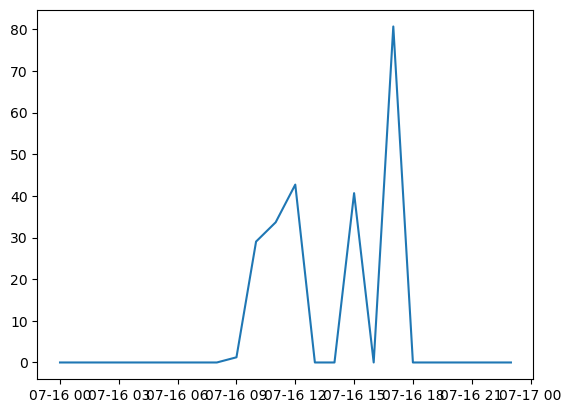

In [ ]:
plt.plot(time,X)
plt.show()

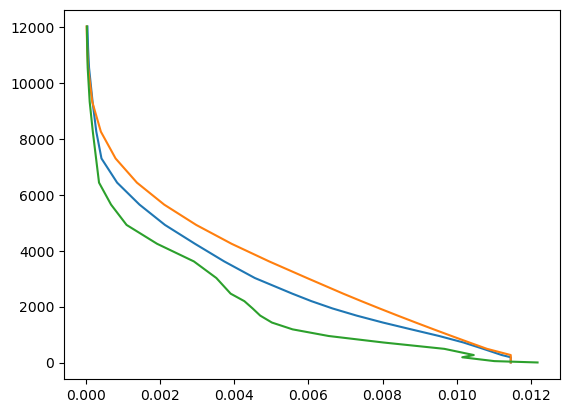

In [ ]:
index = 2
#plt.plot(w_sat(T_d[index],p_new[index,0]) - q_v_parcel[index],Z_new[index],label='T_v_moist')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_l'   )
plt.plot(q_v_parcel[index],Z_new[index],label='q_v_parcel')
plt.plot(q_v_new[index],Z_new[index],label='q_v')
plt.show()

#### LWC and LWP(state)

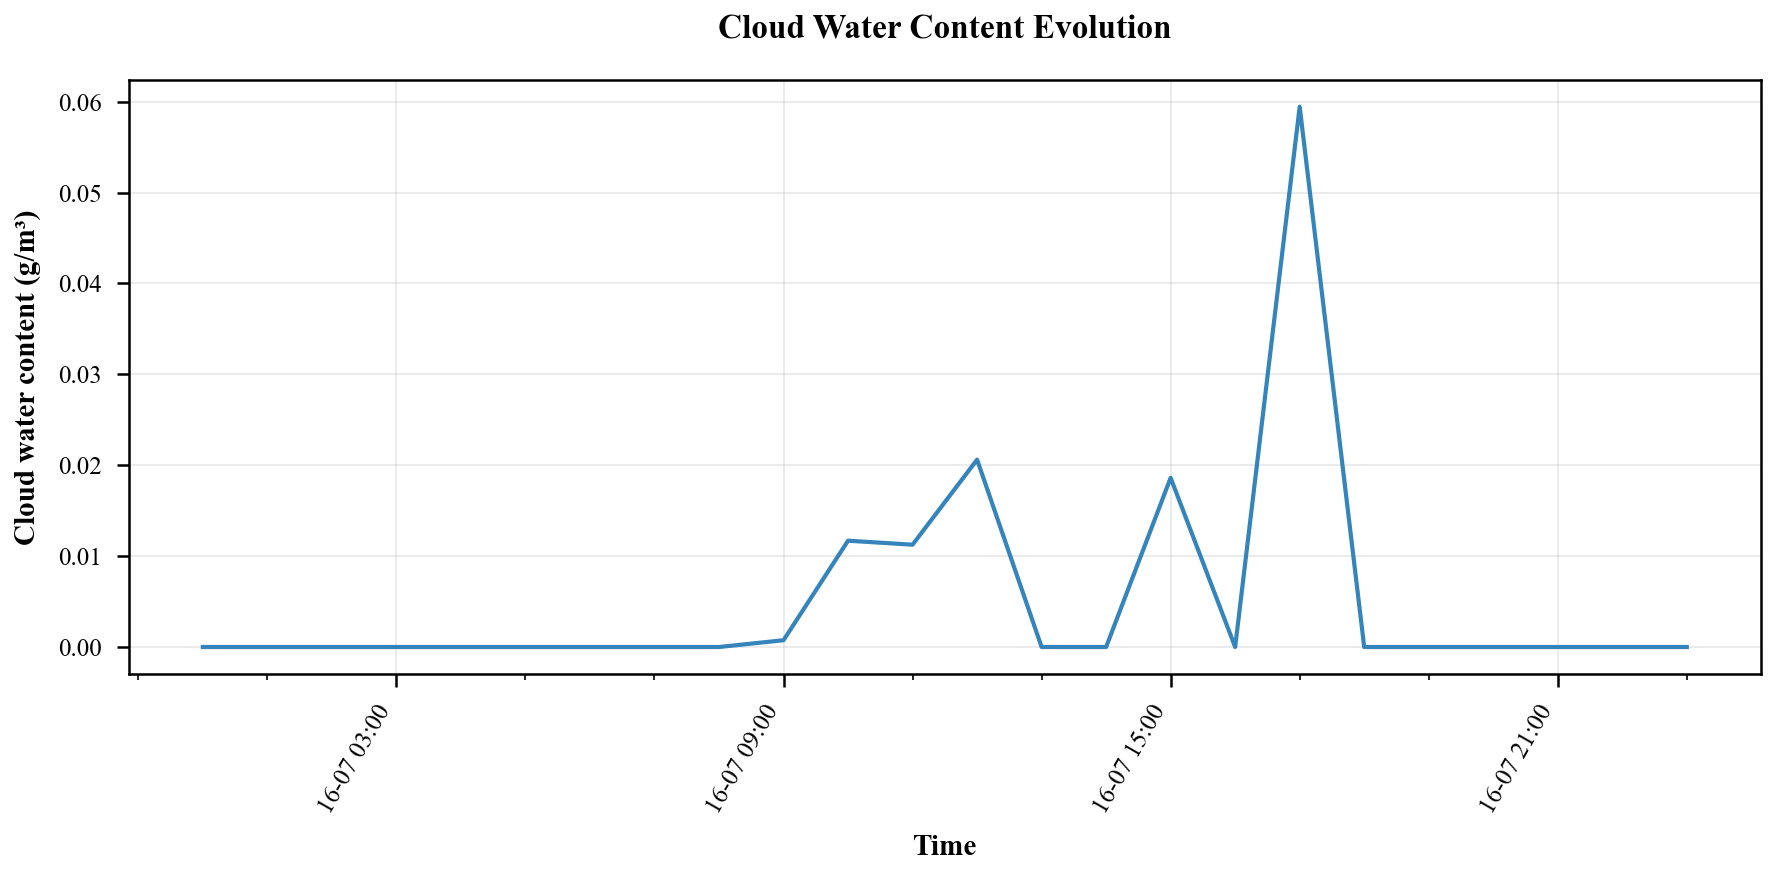

In [ ]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, X / Z_c_new,
        color='#1f77b4',  # Default blue
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud water content (g/m³)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
time_dt

DatetimeIndex(['2024-07-16 00:00:00', '2024-07-16 01:00:00',
               '2024-07-16 02:00:00', '2024-07-16 03:00:00',
               '2024-07-16 04:00:00', '2024-07-16 05:00:00',
               '2024-07-16 06:00:00', '2024-07-16 07:00:00',
               '2024-07-16 08:00:00', '2024-07-16 09:00:00',
               '2024-07-16 10:00:00', '2024-07-16 11:00:00',
               '2024-07-16 12:00:00', '2024-07-16 13:00:00',
               '2024-07-16 14:00:00', '2024-07-16 15:00:00',
               '2024-07-16 16:00:00', '2024-07-16 17:00:00',
               '2024-07-16 18:00:00', '2024-07-16 19:00:00',
               '2024-07-16 20:00:00', '2024-07-16 21:00:00',
               '2024-07-16 22:00:00', '2024-07-16 23:00:00'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_avg)

NameError: name 'hourly_avg' is not defined

In [ ]:
from scipy import stats
stats.pearsonr(R*3600, hourly_acc)

In [ ]:
time_dt

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the plot with improved styling
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data with cleaner formatting
ax.plot(time, P * 3600, label='Model output', 
        color='blue', linewidth=2, alpha=0.8)
ax.plot(time, hourly_acc[:-11]/5, label='Accumulated precipitation Disdrometer', 
        color='red', linewidth=2, alpha=0.8)

# Add labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Precipitation (mm/hour)', fontsize=12)
ax.set_title('Hourly Accumulated Precipitation', fontsize=14, fontweight='bold')

# Format x-axis with dates
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(),
         rotation=rotation,
         ha='right',
         fontsize=12 * SCALE_FACTOR)

# Customize the legend
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Adjust layout and show
plt.tight_layout()
plt.show()